In [1]:
import sys
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

import threading
from concurrent.futures import ThreadPoolExecutor

import magcal
from thread_func import thread_func

### Differential Inversion
L1-L2 penalty

$$
P(\boldsymbol{\delta \beta}) =  \lambda_1 \left\| \boldsymbol{\delta \beta} \right\|_1 + \frac{\lambda_2}{2} \| \boldsymbol{\delta \beta} \|_2^2
$$

In [2]:
# class for L1-L2 penalty inversion
from L1L2_penalty_inv import L1L2

In [3]:
# data misfit
def misfit(f, K, beta_star):
    return 0.5 * np.linalg.norm(f - K.dot(beta_star))**2

# penalty
def pen(beta, alpha):
    pen_1 = np.linalg.norm(beta, 1)
    pen_2 = 0.5 * np.linalg.norm(beta, 2)**2
    pen_all = alpha * pen_1 + (1. - alpha) * pen_2
    return pen_all

In [4]:
def calcCurvature2(x,y):
    
    dif_x = np.gradient(x)
    dif_y = np.gradient(y)
    dif2_x = np.gradient(dif_x)
    dif2_y = np.gradient(dif_y)
    
    curvature = np.abs(dif2_x * dif_y - dif_x * dif2_y) / (dif_x **2 + dif_y **2)**1.5
    return curvature

### 空間領域

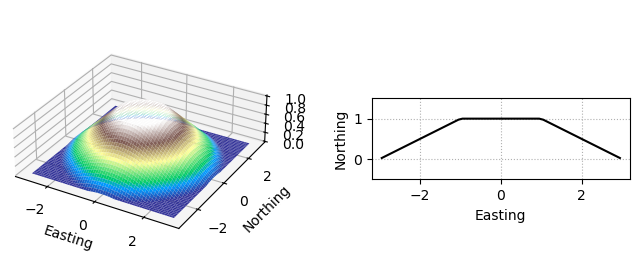

In [5]:
### 地下グリッドの作成: xgrd, ygrd, zgrd ###
# incx, incy, incz : x, y, z方向のグリッド間隔
incx = 0.1
incy = 0.1
incz = 0.1

x = np.arange(-3.0 + 0.5*incx, 3.0, incx)
y = np.arange(-3.0 + 0.5*incy, 3.0, incy)
nx = len(x)
ny = len(y)
X, Y = np.meshgrid(x, y)

# 山型の地形
T = np.zeros(X.shape)
for iy in range(len(y)):
    for ix in range(len(x)):
        r = np.sqrt(X[iy, ix]**2 + Y[iy, ix]**2)
        if r <= 1:
            T[iy, ix] = 1.
        elif (1 <= r) and (r <= 3):
            T[iy, ix] = - 0.5*r + 1.5

### 地下グリッドの作成: xgrd, ygrd, zgrd ###
# 地下の層数 = 30  # 60×60×30
nz = 30
[yy2, zz2, xx2] = np.meshgrid(y, np.zeros(nz), x)

for k in range(nz):
    for i in range(nx):
        for j in range(ny):
            zz2[k, j, i] = T.reshape(-1)[i + nx*j] - incz / 2. - incz*k
            
xgrd = xx2.reshape(-1)
ygrd = yy2.reshape(-1)
zgrd = zz2.reshape(-1)

# 図示用
xfig, yfig, zfig = [], [], []

for i in range(len(xgrd)):
    j = i // (nx*ny)
    
    # 各グリッドの8頂点の座標を格納
    xfig.append([xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, 
                 xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx])
    yfig.append([ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy, 
                 ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy])
    zfig.append([zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, 
                 zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz])

# array化
xfig = np.array(xfig)
yfig = np.array(yfig)
zfig = np.array(zfig)

#dim: ブロックのサイズ
dim = [[incx / 2., incx / 2.], [incy / 2., incy / 2.], [incz / 2., incz / 2.]]

# 東京付近
# 偏角(度)
dec = -7.
# 伏角(度)
inc = 50.

# 図示
fig = plt.figure(figsize = (8, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.)

ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, T, rstride=1, cstride=1, cmap = plt.cm.terrain)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_box_aspect((1,1,0.3))

ax = fig.add_subplot(122)
ys = 29
ax.plot(X[ys, :], T[ys,:], color = "black")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.5, 1.5)
ax.grid(linestyle = "dotted")

### 空中磁気探査（南北, 100 m ASL）

CPU times: total: 6.86 s
Wall time: 6.94 s


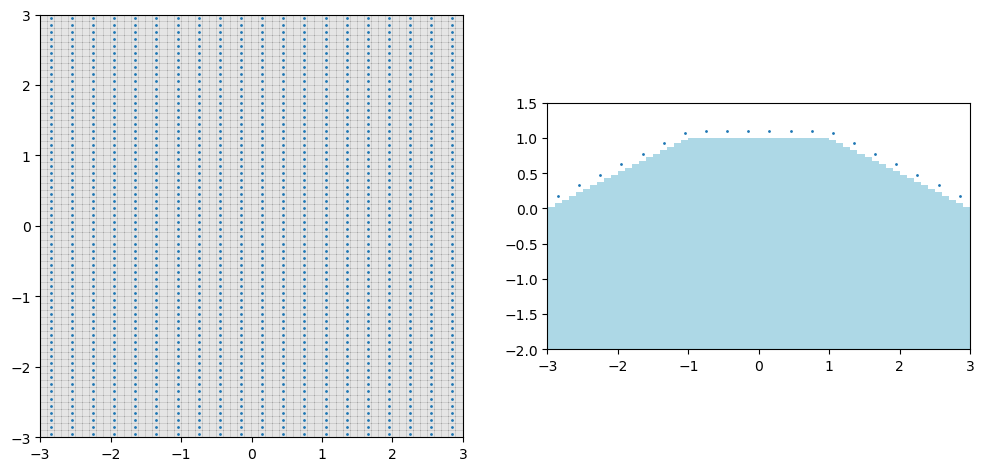

In [6]:
%%time
### 合成データの作成 ###
# 座標： x:東向きを正, y:北向きを正, z:鉛直上向きを正

### 観測点の作成: yobs, zobs ###
[xobs1, yobs1] = np.meshgrid(np.arange(-3.0 + incx + 0.5*incx, 3.0, 3*incx), np.arange(-3.0 + 0.5*incy, 3.0, incy))
xobs1 = xobs1.reshape(-1)
yobs1 = yobs1.reshape(-1)
zobs1 = np.zeros(len(xobs1))

for i in range(len(xobs1)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs1[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs1[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs1[i] = T.reshape(-1)[j] + 0.1 # 地表から100m

# 図示
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs1, yobs1, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs1[(0<yobs1)&(yobs1<incy)], zobs1[(0<yobs1)&(yobs1<incy)], s = 1)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### 空中磁気探査（東西, 100 m ASL）

CPU times: total: 6.98 s
Wall time: 7.05 s


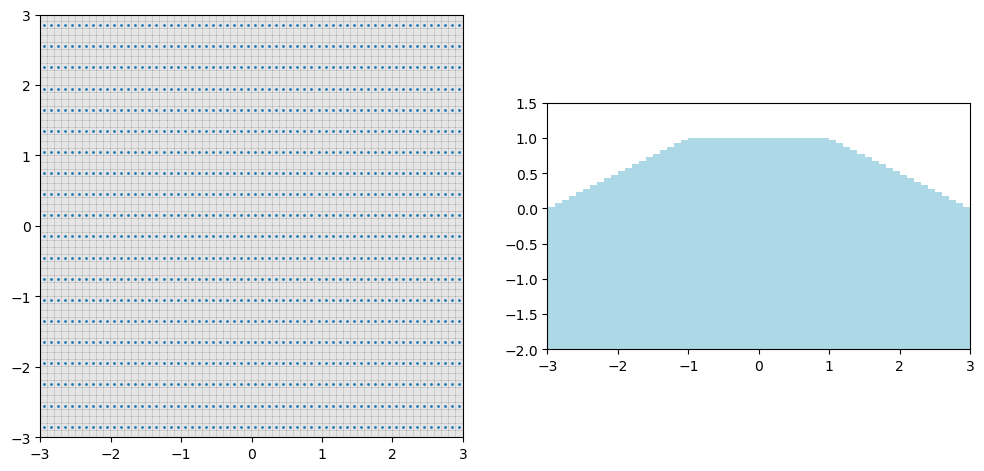

In [7]:
%%time
### 合成データの作成 ###
# 座標： x:東向きを正, y:北向きを正, z:鉛直上向きを正

### 観測点の作成: yobs, zobs ###
[xobs2, yobs2] = np.meshgrid(np.arange(-3.0 + 0.5*incx, 3.0, incx), np.arange(-3.0 + incx + 0.5*incy, 3.0, 3*incy))
xobs2 = xobs2.reshape(-1)
yobs2 = yobs2.reshape(-1)
zobs2 = np.zeros(len(xobs2))

for i in range(len(xobs2)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs2[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs2[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs2[i] = T.reshape(-1)[j] + 0.1 # 地表から100m

# 図示
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs2, yobs2, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs2[(0<yobs2)&(yobs2<incy)], zobs2[(0<yobs2)&(yobs2<incy)], s = 1)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### 空中磁気探査（南北, 60 m ASL）

CPU times: total: 7.31 s
Wall time: 7.35 s


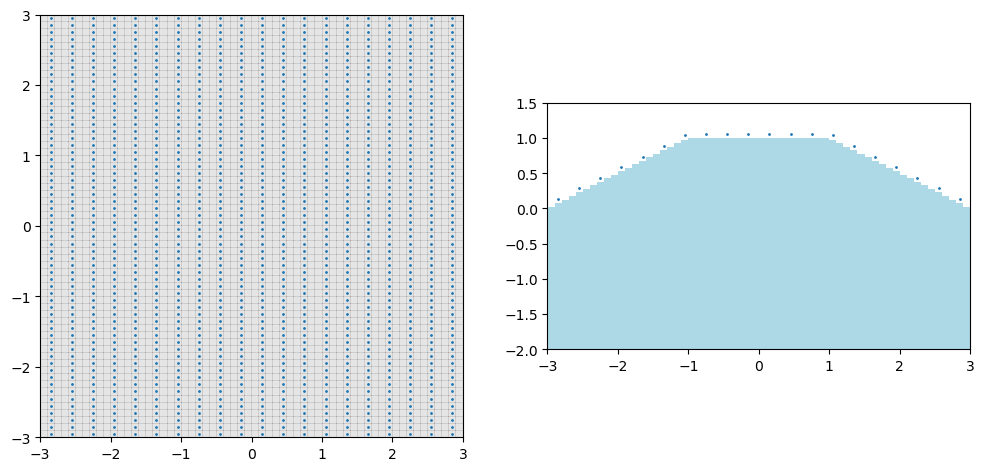

In [8]:
%%time
### 合成データの作成 ###
# 座標： x:東向きを正, y:北向きを正, z:鉛直上向きを正

### 観測点の作成: yobs, zobs ###
[xobs3, yobs3] = np.meshgrid(np.arange(-3.0 + incx + 0.5*incx, 3.0, 3*incx), np.arange(-3.0 + 0.5*incy, 3.0, incy))
xobs3 = xobs3.reshape(-1)
yobs3 = yobs3.reshape(-1)
zobs3 = np.zeros(len(xobs3))

for i in range(len(xobs1)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs3[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs3[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs3[i] = T.reshape(-1)[j] + 0.06 # 地表から60m

# 図示
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs3, yobs3, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs3[(0<yobs3)&(yobs3<incy)], zobs3[(0<yobs3)&(yobs3<incy)], s = 1)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### 空中磁気探査（東西, 50 m ASL）

CPU times: total: 7.34 s
Wall time: 7.43 s


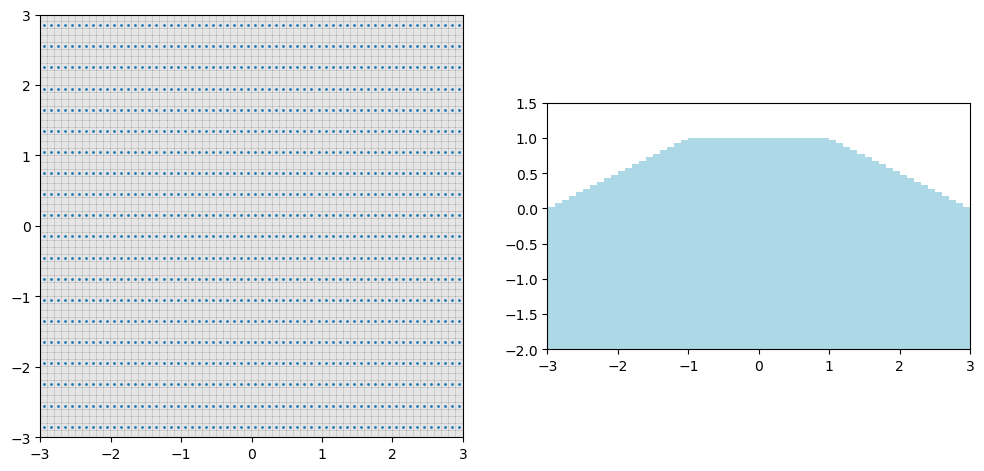

In [9]:
%%time
### 合成データの作成 ###
# 座標： x:東向きを正, y:北向きを正, z:鉛直上向きを正

### 観測点の作成: yobs, zobs ###
[xobs4, yobs4] = np.meshgrid(np.arange(-3.0 + 0.5*incx, 3.0, incx), np.arange(-3.0 + incx + 0.5*incy, 3.0, 3*incy))
xobs4 = xobs4.reshape(-1)
yobs4 = yobs4.reshape(-1)
zobs4 = np.zeros(len(xobs4))

for i in range(len(xobs4)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs4[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs4[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs4[i] = T.reshape(-1)[j] + 0.05 # 地表から50m

# 図示
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs4, yobs4, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs4[(0<yobs4)&(yobs4<incy)], zobs4[(0<yobs4)&(yobs4<incy)], s = 1)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### 核行列

In [10]:
%%time
# threadingを用いた並列計算で核行列を求める
# 単位ベクトル作成
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# スレッドの数（並列計算を動かす数）
n = 12

# 全グリッドに関する計算範囲 i = [0, nz] を n 個に分割
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# ThreadPool に各threadの返り値を格納させる
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs1, yobs1, zobs1, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# 計算結果を取り出し、積み上げて最終的な核行列にする
K1 = []
for res in results:
    Ki = res.result()
    if len(K1) == 0:
        K1 = Ki.copy()
    else:
        K1 = np.hstack((K1, Ki))

[ 0  2  5  7 10 13 15 18 21 23 26 30]
Processed cell index: 36000
Processed cell index: 54000
Processed cell index: 18000
Processed cell index: 0
Processed cell index: 65000
Processed cell index: 47000
Processed cell index: 83000
Processed cell index: 94000
Processed cell index: 76000
Processed cell index: 26000
Processed cell index: 8000
Processed cell index: 55000
Processed cell index: 37000
Processed cell index: 19000
Processed cell index: 1000
Processed cell index: 48000
Processed cell index: 66000
Processed cell index: 84000
Processed cell index: 77000
Processed cell index: 95000
Processed cell index: 27000
Processed cell index: 9000
Processed cell index: 56000
Processed cell index: 38000
Processed cell index: 20000
Processed cell index: 2000
Processed cell index: 67000
Processed cell index: 49000
Processed cell index: 85000
Processed cell index: 78000
Processed cell index: 96000
Processed cell index: 28000
Processed cell index: 10000
Processed cell index: 57000
Processed cell ind

In [11]:
%%time
# threadingを用いた並列計算で核行列を求める
# 単位ベクトル作成
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# スレッドの数（並列計算を動かす数）
n = 12

# 全グリッドに関する計算範囲 i = [0, nz] を n 個に分割
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# ThreadPool に各threadの返り値を格納させる
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs2, yobs2, zobs2, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# 計算結果を取り出し、積み上げて最終的な核行列にする
K2 = []
for res in results:
    Ki = res.result()
    if len(K2) == 0:
        K2 = Ki.copy()
    else:
        K2 = np.hstack((K2, Ki))

[ 0  2  5  7 10 13 15 18 21 23 26 30]
Processed cell index: 0
Processed cell index: 18000
Processed cell index: 36000
Processed cell index: 54000
Processed cell index: 83000
Processed cell index: 65000
Processed cell index: 47000
Processed cell index: 94000
Processed cell index: 76000
Processed cell index: 26000
Processed cell index: 8000
Processed cell index: 1000
Processed cell index: 55000
Processed cell index: 37000
Processed cell index: 19000
Processed cell index: 66000
Processed cell index: 84000
Processed cell index: 48000
Processed cell index: 95000
Processed cell index: 77000
Processed cell index: 27000
Processed cell index: 9000
Processed cell index: 56000
Processed cell index: 2000
Processed cell index: 38000
Processed cell index: 20000
Processed cell index: 67000
Processed cell index: 85000
Processed cell index: 49000
Processed cell index: 96000
Processed cell index: 78000
Processed cell index: 28000
Processed cell index: 10000
Processed cell index: 57000
Processed cell ind

In [12]:
%%time
# threadingを用いた並列計算で核行列を求める
# 単位ベクトル作成
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# スレッドの数（並列計算を動かす数）
n = 12

# 全グリッドに関する計算範囲 i = [0, nz] を n 個に分割
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# ThreadPool に各threadの返り値を格納させる
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs3, yobs3, zobs3, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# 計算結果を取り出し、積み上げて最終的な核行列にする
K3 = []
for res in results:
    Ki = res.result()
    if len(K3) == 0:
        K3 = Ki.copy()
    else:
        K3 = np.hstack((K3, Ki))

[ 0  2  5  7 10 13 15 18 21 23 26 30]
Processed cell index: 0
Processed cell index: 18000
Processed cell index: 36000
Processed cell index: 54000
Processed cell index: 65000
Processed cell index: 83000
Processed cell index: 47000
Processed cell index: 94000
Processed cell index: 76000
Processed cell index: 26000
Processed cell index: 8000
Processed cell index: 19000
Processed cell index: 37000
Processed cell index: 55000
Processed cell index: 1000
Processed cell index: 66000
Processed cell index: 84000
Processed cell index: 48000
Processed cell index: 95000
Processed cell index: 77000
Processed cell index: 27000
Processed cell index: 9000
Processed cell index: 20000
Processed cell index: 38000
Processed cell index: 56000
Processed cell index: 2000
Processed cell index: 85000
Processed cell index: 67000
Processed cell index: 49000
Processed cell index: 96000
Processed cell index: 78000
Processed cell index: 28000
Processed cell index: 10000
Processed cell index: 21000
Processed cell ind

In [13]:
%%time
# threadingを用いた並列計算で核行列を求める
# 単位ベクトル作成
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# スレッドの数（並列計算を動かす数）
n = 12

# 全グリッドに関する計算範囲 i = [0, nz] を n 個に分割
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# ThreadPool に各threadの返り値を格納させる
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs4, yobs4, zobs4, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# 計算結果を取り出し、積み上げて最終的な核行列にする
K4 = []
for res in results:
    Ki = res.result()
    if len(K4) == 0:
        K4 = Ki.copy()
    else:
        K4 = np.hstack((K4, Ki))

[ 0  2  5  7 10 13 15 18 21 23 26 30]
Processed cell index: 18000
Processed cell index: 36000
Processed cell index: 0
Processed cell index: 54000
Processed cell index: 47000
Processed cell index: 65000
Processed cell index: 83000
Processed cell index: 76000
Processed cell index: 94000
Processed cell index: 26000
Processed cell index: 8000
Processed cell index: 55000
Processed cell index: 1000
Processed cell index: 37000
Processed cell index: 19000
Processed cell index: 48000
Processed cell index: 66000
Processed cell index: 84000
Processed cell index: 77000
Processed cell index: 95000
Processed cell index: 27000
Processed cell index: 9000
Processed cell index: 2000
Processed cell index: 56000
Processed cell index: 20000
Processed cell index: 38000
Processed cell index: 49000
Processed cell index: 67000
Processed cell index: 85000
Processed cell index: 78000
Processed cell index: 96000
Processed cell index: 28000
Processed cell index: 10000
Processed cell index: 3000
Processed cell inde

In [14]:
# Depth weighting
w1 = np.linalg.norm(K1, axis=0)
X1 = K1 / w1

w2 = np.linalg.norm(K2, axis=0)
X2 = K2 / w2

w3 = np.linalg.norm(K3, axis=0)
X3 = K3 / w3

w4 = np.linalg.norm(K4, axis=0)
X4 = K4 / w4

### Input models

In [15]:
### 磁化構造  ###

# 回転楕円状消磁源  
zcenter = -0.2
a_rad = 0.5 # 半径
b_rad = 0.5
c_rad = 0.5

# ------------------------------------------------------------ #

# Time1
beta1 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta1[k] = -4

# Time2
beta2 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta2[k] = -2

# Time3
beta3 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta3[k] = 1

# Time4
beta4 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta4[k] = 5

# ------------------------------------------------------------ #

# 磁気異常の計算
f1_row = K1.dot(beta1)
f2_row = K2.dot(beta2)
f3_row = K3.dot(beta3)
f4_row = K4.dot(beta4)

# ガウシアンノイズを加える 
np.random.seed(42)
noise1 = np.random.normal(loc=0, scale=5.0, size=len(f1_row)) # 5nT
noise2 = np.random.normal(loc=0, scale=5.0, size=len(f2_row)) # 5nT
noise3 = np.random.normal(loc=0, scale=5.0, size=len(f3_row)) # 5nT
noise4 = np.random.normal(loc=0, scale=5.0, size=len(f4_row)) # 5nT
fobs1 = f1_row + noise1
fobs2 = f2_row + noise2
fobs3 = f3_row + noise3
fobs4 = f4_row + noise4

bb1 = beta1.reshape(nz, ny, nx)
bb2 = beta2.reshape(nz, ny, nx)
bb3 = beta3.reshape(nz, ny, nx)
bb4 = beta4.reshape(nz, ny, nx)

<timed exec>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


CPU times: total: 10.8 s
Wall time: 10.9 s


<timed exec>:286: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:316: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:346: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:376: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


Text(0.5, 1.0, 'Magnetic anomaly (nT)')

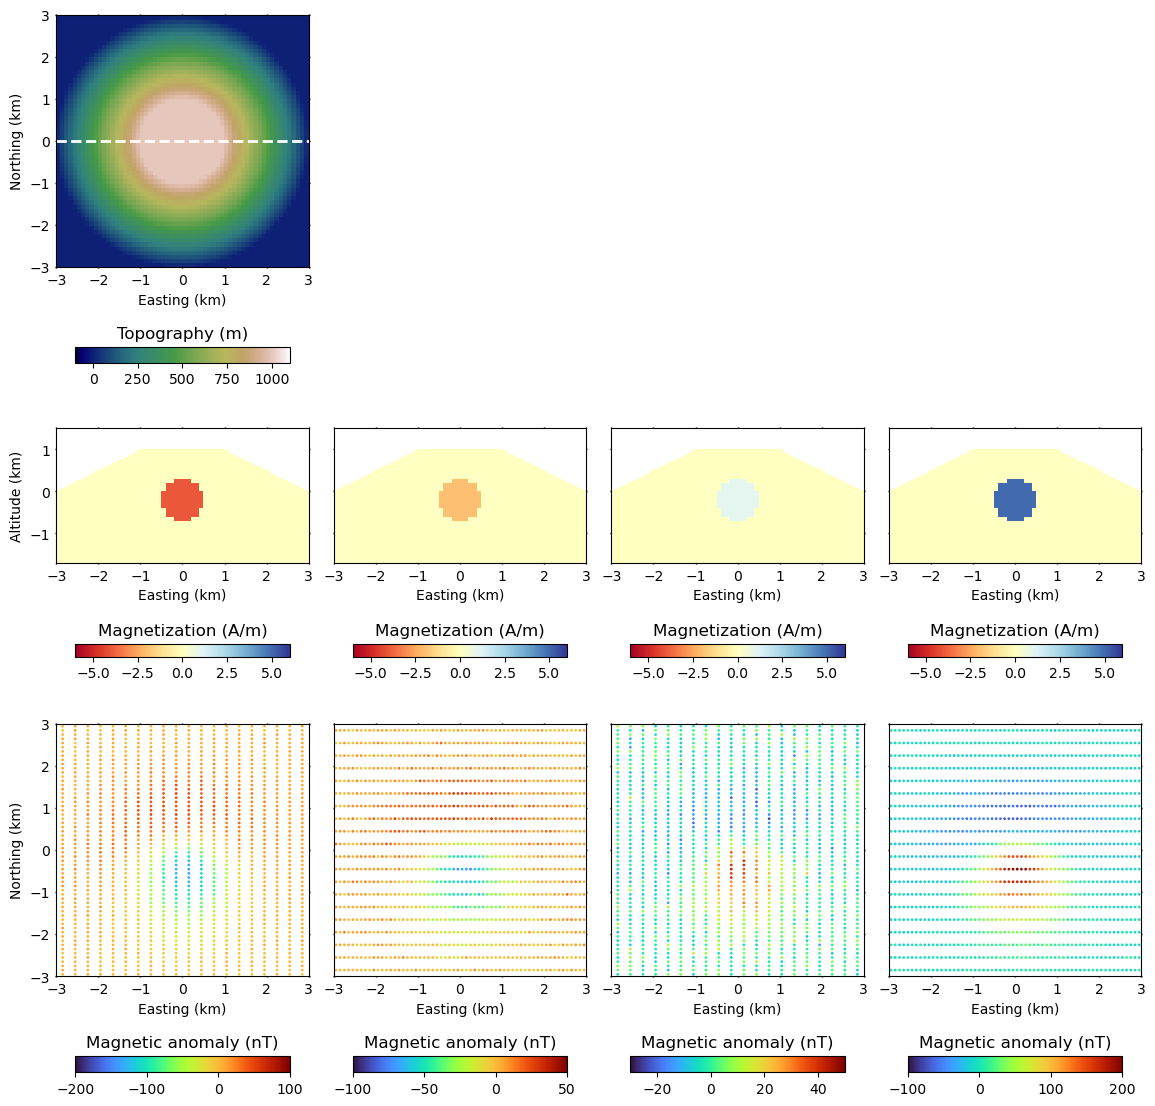

In [16]:
%%time
# カラーマップ
cmap = cm.get_cmap("gist_earth")
norm = Normalize(vmin = -100, vmax = 1100)

# 図示
fig = plt.figure(figsize = (14, 12.5))
plt.subplots_adjust(wspace=0.1, hspace=-0.3)

#--- Topography ---#

ax = fig.add_subplot(541)
p = ax.pcolor(X, Y, T*1e3, cmap = cmap)
p.set_clim(-100, 1100)

ax.plot([-3.0, 3.0], [0.0, 0.0], linestyle='--', color='white', linewidth=2)

ax.set_aspect("equal")
ax.set_xlim(-3, )
ax.set_ylim(-3, )
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Topography (m)", fontsize = 12)


#--- Input model ---#

# カラーマップ
cmap = cm.get_cmap("RdYlBu")
norm = Normalize(vmin = -6, vmax = 6)

# T = T1
ax = fig.add_subplot(5,4,9)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta1[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T2
ax = fig.add_subplot(5,4,10)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta2[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T3
ax = fig.add_subplot(5,4,11)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta3[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T4
ax = fig.add_subplot(5,4,12)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta4[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_4$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

### data ###

# T = T_1
ax = fig.add_subplot(5,4,17)
p = ax.scatter(xobs1, yobs1, c = fobs1, cmap = "turbo", s = 1)
p.set_clim(-200, 100)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 100)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_2
ax = fig.add_subplot(5,4,18)
p = ax.scatter(xobs2, yobs2, c = fobs2, cmap = "turbo", s = 1)
p.set_clim(-100, 50)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -100, vmax = 50)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_3
ax = fig.add_subplot(5,4,19)
p = ax.scatter(xobs3, yobs3, c = fobs3, cmap = "turbo", s = 1)
p.set_clim(-30, 50)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -30, vmax = 50)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_4
ax = fig.add_subplot(5,4,20)
p = ax.scatter(xobs4, yobs4, c = fobs4, cmap = "turbo", s = 1)
p.set_clim(-100, 200)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -100, vmax = 200)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

### 交点のみを抽出

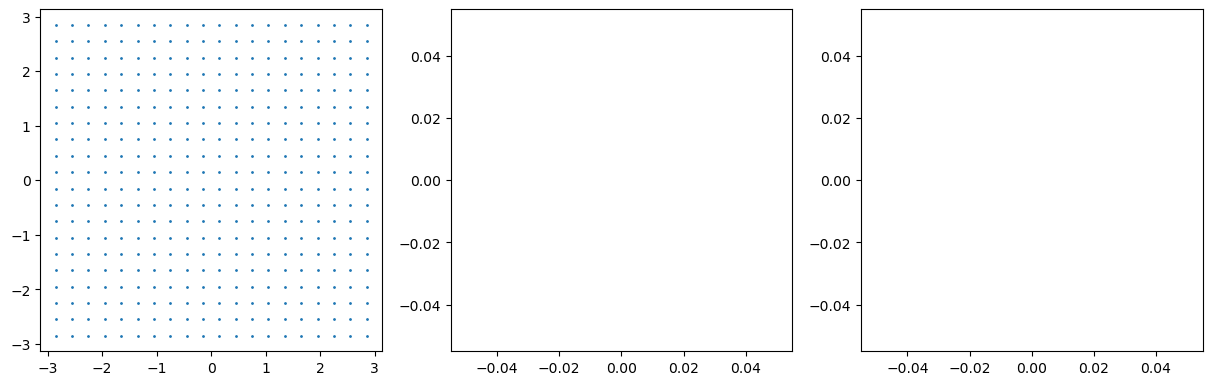

In [17]:
# diff  # T_2 - T_1
xobs_del12_all = []
yobs_del12_all = []
zobs_del12_all = []
fobs_del12_all = []

# 検索
for i in range(len(xobs1)):
    for j in range(len(xobs2)):
        
        if (np.abs(xobs1[i] - xobs2[j]) < 1e-3) & (np.abs(yobs1[i] - yobs2[j]) < 1e-3) & (np.abs(zobs1[i] - zobs2[j]) < 1e-3):

            # 座標
            xobs_del12_all.append(xobs1[i])
            yobs_del12_all.append(yobs1[i])
            zobs_del12_all.append(zobs1[i])

            # data
            fobs_del12_all.append(fobs2[j] - fobs1[i])

# diff  # T_3 - T_2
xobs_del23_all = []
yobs_del23_all = []
zobs_del23_all = []
fobs_del23_all = []

# 検索
for i in range(len(xobs2)):
    for j in range(len(xobs3)):
        
        if (np.abs(xobs2[i] - xobs3[j]) < 1e-3) & (np.abs(yobs2[i] - yobs3[j]) < 1e-3) & (np.abs(zobs2[i] - zobs3[j]) < 1e-3):

            # 座標
            xobs_del23_all.append(xobs2[i])
            yobs_del23_all.append(yobs2[i])
            zobs_del23_all.append(zobs2[i])

            # data
            fobs_del23_all.append(fobs3[j] - fobs2[i])
            
# diff  # T_4 - T_3
xobs_del34_all = []
yobs_del34_all = []
zobs_del34_all = []
fobs_del34_all = []

# 検索
for i in range(len(xobs3)):
    for j in range(len(xobs4)):
        
        if (np.abs(xobs3[i] - xobs4[j]) < 1e-3) & (np.abs(yobs3[i] - yobs4[j]) < 1e-3) & (np.abs(zobs3[i] - zobs4[j]) < 1e-3):

            # 座標
            xobs_del34_all.append(xobs3[i])
            yobs_del34_all.append(yobs3[i])
            zobs_del34_all.append(zobs3[i])

            # data
            fobs_del34_all.append(fobs4[j] - fobs3[i])

# 図示
fig = plt.figure(figsize = (15, 5))

ax1 = fig.add_subplot(131)
p = ax1.scatter(xobs_del12_all, yobs_del12_all, s = 1)
#plt.colorbar(p, orientation = "horizontal")
#p.set_clim(-5, 5)
ax1.set_aspect("equal")

ax2 = fig.add_subplot(132)
p = ax2.scatter(xobs_del23_all, yobs_del23_all, s = 1)
#plt.colorbar(p, orientation = "horizontal")
#p.set_clim(-15, 15)
ax2.set_aspect("equal")

ax3 = fig.add_subplot(133)
p = ax3.scatter(xobs_del34_all, yobs_del34_all, s = 1)
#plt.colorbar(p, orientation = "horizontal")
#p.set_clim(-20, 20)
ax3.set_aspect("equal")

In [18]:
%%time
# threadingを用いた並列計算で核行列を求める
# 単位ベクトル作成
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# スレッドの数（並列計算を動かす数）
n = 12

# 全グリッドに関する計算範囲 i = [0, nz] を n 個に分割
p = np.linspace(0, nz-1, n).astype(int)
p[-1] += 1
print(p)

# ThreadPool に各threadの返り値を格納させる
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs_del12_all, yobs_del12_all, zobs_del12_all, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# 計算結果を取り出し、積み上げて最終的な核行列にする
K_del12 = []
for res in results:
    Ki = res.result()
    if len(K_del12) == 0:
        K_del12 = Ki.copy()
    else:
        K_del12 = np.hstack((K_del12, Ki))

[ 0  2  5  7 10 13 15 18 21 23 26 30]
Processed cell index: 0
Processed cell index: 18000
Processed cell index: 54000
Processed cell index: 36000
Processed cell index: 47000
Processed cell index: 65000
Processed cell index: 83000
Processed cell index: 94000
Processed cell index: 76000
Processed cell index: 8000
Processed cell index: 26000
Processed cell index: 19000
Processed cell index: 37000
Processed cell index: 55000
Processed cell index: 1000
Processed cell index: 48000Processed cell index: 84000

Processed cell index: 66000
Processed cell index: 95000
Processed cell index: 77000
Processed cell index: 9000
Processed cell index: 27000
Processed cell index: 20000
Processed cell index: 38000
Processed cell index: 56000
Processed cell index: 2000
Processed cell index: 49000
Processed cell index: 85000
Processed cell index: 67000
Processed cell index: 96000
Processed cell index: 78000
Processed cell index: 10000
Processed cell index: 28000
Processed cell index: 39000
Processed cell ind

In [19]:
# Depth weighting
w_del12 = np.linalg.norm(K_del12, axis=0)
X_del12 = K_del12 / w_del12
XXT_del12 = X_del12.dot(X_del12.T)

X_del12.shape, 

((400, 108000),)

### Differential Inversion

In [20]:
# hyper-parameters
lams = np.power(10., np.arange(0.0, 2.6, 0.25))
print("lams = {}".format(lams))

# ratio of L1 norm and L2 norm
alpha_ = 0.9

lams = [  1.           1.77827941   3.16227766   5.62341325  10.
  17.7827941   31.6227766   56.23413252 100.         177.827941
 316.22776602]


In [21]:
%%time
params_all = []
betas_del12_all = []

for li in range(len(lams)):

    params_all.append(lams[li])
    
    l_1 = lams[li] * alpha_
    l_2 = lams[li] * (1. - alpha_)
    print("λ1 = {}, λ2 = {}".format(l_1, l_2))
    
    # インバージョン解析を実行
    model1 = L1L2(l_1, l_2, rho_=1.0, eta_=0.0, fit_intercept = False, eps_ADMM = 1.e-3)
    model1.algorithm(X_del12, fobs_del12_all, w_del12)
    beta_sim_del12 = model1.beta_ / w_del12

    betas_del12_all.append(beta_sim_del12)

# ndarry
params_all = np.array(params_all)
betas_del12_all = np.array(betas_del12_all)

λ1 = 0.9, λ2 = 0.09999999999999998
intercept = False
no-constrained
iter = 0, delta = 0.08646416027894246
Converged at iteration 113
λ1 = 1.6004514690350304, λ2 = 0.17782794100389224
intercept = False
no-constrained
iter = 0, delta = 0.08765709566912777
Converged at iteration 197
λ1 = 2.8460498941515415, λ2 = 0.3162277660168379
intercept = False
no-constrained
iter = 0, delta = 0.08765709566912777
Converged at iteration 353
λ1 = 5.061071926713142, λ2 = 0.562341325190349
intercept = False
no-constrained
iter = 0, delta = 0.08765709566912777
Converged at iteration 610
λ1 = 9.0, λ2 = 0.9999999999999998
intercept = False
no-constrained
iter = 0, delta = 0.08765709566912777
Converged at iteration 989
λ1 = 16.004514690350305, λ2 = 1.7782794100389225
intercept = False
no-constrained
iter = 0, delta = 0.08765709566912777
iter = 1000, delta = 0.0012876785534329084
Converged at iteration 1434
λ1 = 28.460498941515414, λ2 = 3.1622776601683786
intercept = False
no-constrained
iter = 0, delta = 0.08

In [22]:
import pickle
with open('Params_case_1_2_differential.pickle', 'wb') as f:
    pickle.dump(params_all, f)
with open('Betas_del12_case_1_2_differential.pickle', 'wb') as f:
    pickle.dump(betas_del12_all, f)

In [23]:
# calc rss, pen
# T2 - T1
rss_temp_del12 = []
pen_temp_del12 = []
for i in range(len(lams)):
    rss_temp_del12.append(misfit(fobs_del12_all, K_del12, betas_del12_all[i]))
    pen_temp_del12.append(pen(betas_del12_all[i]*w_del12, alpha=0.9))

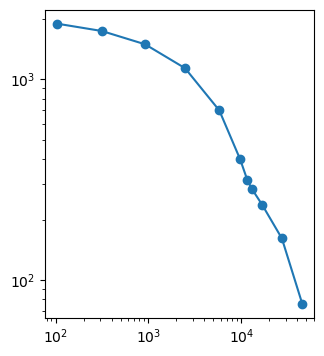

In [24]:
# L-curve
fig = plt.figure(figsize = (16, 4))

ax = fig.add_subplot(141)
ax.loglog(rss_temp_del12, pen_temp_del12, "o-")
#ax.plot(rss_temp_del12, pen_temp_del12, "o-")


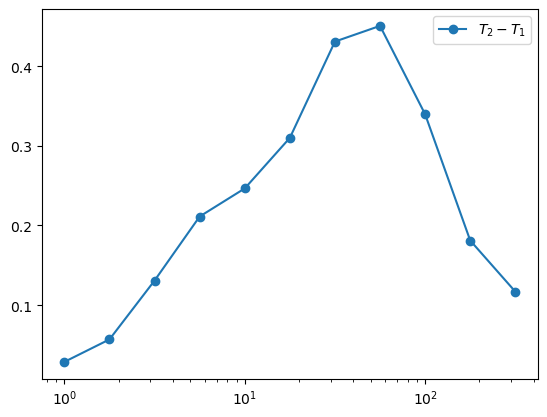

In [25]:
plt.semilogx(lams, calcCurvature2(np.log(rss_temp_del12), np.log(pen_temp_del12)), "o-", label = "$T_2 - T_1$")
plt.legend()